In [1]:
# Download dataset
import kagglehub
from dotenv import load_dotenv

/home/nguyen/.local/bin/anaconda3/envs/uts_ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
path = kagglehub.dataset_download(handle="furcifer/fane-facial-expressions-and-emotion-dataset")
print(path)

/home/nguyen/.cache/kagglehub/datasets/furcifer/fane-facial-expressions-and-emotion-dataset/versions/1


In [3]:
import os
import glob
import cv2
import numpy as np
from tqdm import tqdm
from utilities.modifications.preprocess_data import preprocess_image

In [4]:
image_size = 64
data = []
labels = {}
categories = []

dataset_path = os.path.join(path, "fane_data")

# collect class folders
category_folders = sorted(
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
)
categories.extend(category_folders)

# build label map
for idx, c in enumerate(categories):
    labels[c] = idx

print(categories)
print(labels)

# supported extensions
exts = (".jpg", ".jpeg", ".png", ".bmp")

# collect and process
for category in categories:
    full_category_path = os.path.join(dataset_path, category)
    class_num = labels[category]

    # recursively gather files
    files = []
    for root, _, _ in os.walk(full_category_path):
        for ext in exts:
            files.extend(glob.glob(os.path.join(root, f"*{ext}")))

    for img_path in tqdm(files, desc=f"Processing {category}", leave=False):
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Unable to load image {img_path}. Skipping.")
                continue

            img = cv2.resize(img, (image_size, image_size))
            img = preprocess_image(img)
            data.append([img, class_num]) # [image, label]
        except Exception as e:
            print(f"Skip {img_path}: {e}")
            continue

# single shuffle at the end (reproducible)
rng = np.random.default_rng(42)
rng.shuffle(data)

['angry', 'confused', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'shy', 'surprise']
{'angry': 0, 'confused': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'shy': 7, 'surprise': 8}


Processing happy:  77%|███████████████████████████████████████████████████████████████████████████████████████████████████▉                              | 1478/1922 [00:00<00:00, 7230.54it/s]

In [5]:
X = [img for img, label in data]
y = [label for img, label in data]

X = np.array(X).reshape(-1, image_size, image_size, 1)
y = np.array(y)

print (X.shape)

(16912, 64, 64, 1)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from networks.convnet import build_convnet
import tensorflow as tf
import keras

cnn = build_convnet(n_classes=9, drop_out=0.25, input_shape=(64, 64, 1))
cnn.summary()

2025-10-06 01:56:14.017423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1759676175.739813 1354953 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14751 MB memory:  -> device: 0, name: Quadro RTX 5000 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 5,397,257 (20.59 MB)

 Trainable params: 5,393,289 (20.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [8]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

# Callbacks for early stopping and saving the best model
callbacks = [
    keras.callbacks.ModelCheckpoint("models/convnet.keras", save_best_only=True, monitor="val_accuracy", verbose=1, mode="max"),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_accuracy', verbose=1, min_delta=0.002, mode="min", cooldown=1),
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, verbose=1, min_delta=0, monitor="val_accuracy", mode="max"),
]

In [9]:
history = cnn.fit(
    x=X_train,
    y=y_train,
    batch_size=64,
    validation_split=0.2,
    epochs=200,
    callbacks=callbacks,
)

Epoch 1/200


2025-10-06 01:56:19.620209: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe90401fde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-06 01:56:19.620223: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro RTX 5000 with Max-Q Design, Compute Capability 7.5
2025-10-06 01:56:19.693011: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-06 01:56:20.154773: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2025-10-06 01:56:20.753305: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custo

  3/170 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.1719 - loss: 2.5980  

I0000 00:00:1759676187.317924 1355345 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1795 - loss: 2.3834

2025-10-06 01:56:34.381733: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-06 01:56:34.417340: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,512,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,128,16,16]{3,2,1,0}, f32[512,128,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cu

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1797 - loss: 2.3826

2025-10-06 01:56:40.630211: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[18,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-06 01:56:40.646991: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[18,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,64,32,32]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__


Epoch 1: val_accuracy improved from None to 0.15373, saving model to models/convnet.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.2063 - loss: 2.2542 - val_accuracy: 0.1537 - val_loss: 2.5153 - learning_rate: 0.0010
Epoch 2/200
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2657 - loss: 2.0392
Epoch 2: val_accuracy improved from 0.15373 to 0.17110, saving model to models/convnet.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.2693 - loss: 2.0135 - val_accuracy: 0.1711 - val_loss: 2.3889 - learning_rate: 0.0010
Epoch 3/200
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3187 - loss: 1.8819
Epoch 3: val_accuracy improved from 0.17110 to 0.21803, saving model to models/convnet.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3140 - loss: 1.8876 - val_accuracy: 0.2180 - val_loss: 2.1164 - learning_rate: 0.0010
Epoch 4/200
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3582 - loss: 1.7872
Epoch 4: val_accuracy improved f

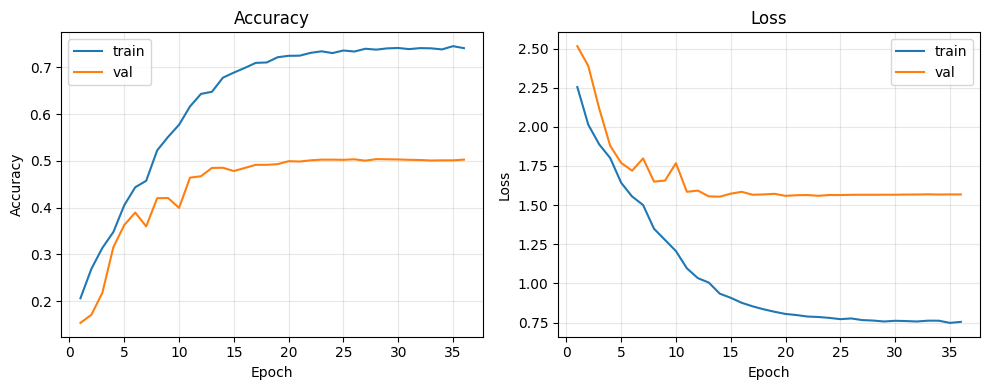

In [10]:
import matplotlib.pyplot as plt

# pull safely (works with both new and old key names)
acc      = history.history.get("accuracy", history.history.get("acc"))
val_acc  = history.history.get("val_accuracy", history.history.get("val_acc"))
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, label="train")
plt.plot(epochs, val_acc, label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# prediction with the best model
final_cnn = keras.saving.load_model("models/convnet.keras")
final_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 16,183,837 (61.74 MB)

 Trainable params: 5,393,289 (20.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

 Optimizer params: 10,786,580 (41.15 MB)

In [12]:
from utilities.evaluations.confusion_matrix import plot_confusion_matrix
from utilities.evaluations.math_metrics import calculate_multiclass_metrics
y_pred_raw = final_cnn.predict(X_test)
y_pred = np.argmax(y_pred_raw, axis=1)

2025-10-06 02:00:46.886520: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-06 02:00:46.907116: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,32,32]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__

101/106 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

2025-10-06 02:00:48.740508: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,1,64,64]{3,2,1,0}, f32[64,1,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-06 02:00:48.759967: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,64,32,32]{3,2,1,0}, f32[128,64,5,5]{3,2,1,0}, f32[128]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__

106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


In [13]:
calculate_multiclass_metrics(y_test, y_pred, num_classes=9)

{0: {'accuracy': 0.8157649253731343,
  'precision': 0.4051094890510949,
  'recall': 0.3236151603498542,
  'f1_score': 0.359805510534846},
 1: {'accuracy': 0.84167468719923,
  'precision': 0.3106796116504854,
  'recall': 0.2549800796812749,
  'f1_score': 0.2800875273522976},
 2: {'accuracy': 0.8384467881112176,
  'precision': 0.36018957345971564,
  'recall': 0.2733812949640288,
  'f1_score': 0.310838445807771},
 3: {'accuracy': 0.8056195301704284,
  'precision': 0.6258169934640523,
  'recall': 0.6649305555555556,
  'f1_score': 0.6447811447811448},
 4: {'accuracy': 0.8692842942345924,
  'precision': 0.6357615894039735,
  'recall': 0.7461139896373057,
  'f1_score': 0.6865315852205006},
 5: {'accuracy': 0.8336510962821735,
  'precision': 0.5230769230769231,
  'recall': 0.46703296703296704,
  'f1_score': 0.49346879535558785},
 6: {'accuracy': 0.7647573240052471,
  'precision': 0.5069444444444444,
  'recall': 0.666058394160584,
  'f1_score': 0.5757097791798108},
 7: {'accuracy': 0.8745,
  'p

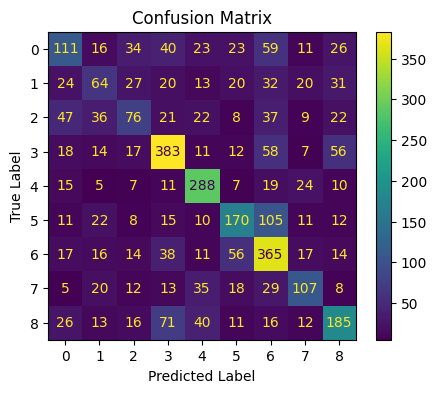

In [14]:
plot_confusion_matrix(y_test, y_pred)